<a href="https://colab.research.google.com/github/Alamsyah-WM/Classification-DBP-Binding-vs-Non-Binding/blob/Finale/MLP_ESM2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Setup and Preparation
Upper Branch: ESM2_t6_8M with SupCon + MLP Classifier

In [1]:
!pip install torch torchvision torchaudio
!pip install transformers scikit-learn pandas numpy tqdm

# --- IMPORTING LIBRARIES ---
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import pandas as pd
import numpy as np
import os
import random
from tqdm import tqdm

from transformers import AutoTokenizer, AutoModel
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    matthews_corrcoef, roc_auc_score, confusion_matrix, classification_report
)
import matplotlib.pyplot as plt
import seaborn as sns

# Device Configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(42)

Using device: cuda


## Data Preprocessing

In [2]:
# A. Cleaning Function
def cleaning_dataset(df, dataset_name=None):
    if df is None or df.empty:
        print(f"Dataset {dataset_name} is empty. No cleaning required.")
        return df

    # Check if 'set' column exists (used for existing splits)
    if 'set' in df.columns:
        df_sorted = df.sort_values(by='set', ascending=True)
        # Drop duplicates based on sequence, keeping first found
        df_clean = df_sorted.drop_duplicates(subset='sequence', keep='first').reset_index(drop=True)
    else:
        df_clean = df.drop_duplicates(subset='sequence', keep='first').reset_index(drop=True)

    print(f"Dataset {dataset_name} cleaned: {len(df) - len(df_clean)} rows")
    return df_clean

In [3]:
# B. ESM2 Embedding Generation with MEAN POOLING (Train 4 config)
@torch.no_grad()
def extract_esm2_embeddings(sequences, tokenizer, model, device, batch_size=8):
    """
    Extract mean-pooled ESM2 embeddings (320-dim from t6_8M model).
    Uses MEAN POOLING across all tokens (not just CLS) - Train 4 configuration.
    """
    all_embeddings = []
    model.eval()

    for i in tqdm(range(0, len(sequences), batch_size), desc="Extracting ESM2 embeddings"):
        batch = sequences[i:i+batch_size]

        # Tokenize
        tokens = tokenizer(
            batch,
            padding=True,
            truncation=True,
            max_length=1024,
            return_tensors='pt'
        )
        tokens = {k: v.to(device) for k, v in tokens.items()}

        # Get embeddings
        outputs = model(**tokens)

        # MEAN POOLING (Train 4 configuration) - average across all tokens
        embeddings = outputs.last_hidden_state.mean(dim=1)  # Shape: (batch_size, 320)
        all_embeddings.append(embeddings.cpu())

    return torch.cat(all_embeddings, dim=0)

In [4]:
# C. Main Data Pipeline Function
def prepare_data(csv_path, output_dir, dataset_name="dataset", tokenizer=None, model=None, device='cuda'):
    """
    Pipeline: Load CSV -> Clean -> Check Cache -> Generate Embeddings -> Save -> Return Data
    """
    # Paths for cached files
    os.makedirs(output_dir, exist_ok=True)
    train_emb_path = os.path.join(output_dir, f"X_{dataset_name}_train.pt")
    test_emb_path = os.path.join(output_dir, f"X_{dataset_name}_test.pt")
    train_lbl_path = os.path.join(output_dir, f"y_{dataset_name}_train.npy")
    test_lbl_path = os.path.join(output_dir, f"y_{dataset_name}_test.npy")

    # 1. Check if cache exists
    if os.path.exists(train_emb_path) and os.path.exists(test_lbl_path):
        print(f"Loading cached embeddings from {output_dir}...")
        X_train = torch.load(train_emb_path)
        y_train = np.load(train_lbl_path)
        X_test = torch.load(test_emb_path)
        y_test = np.load(test_lbl_path)
        return X_train, y_train, X_test, y_test

    print(f"Cache not found. Processing {csv_path}...")

    # 2. Load and Clean
    df = pd.read_csv(csv_path)
    df = cleaning_dataset(df, dataset_name)

    # 3. Split using 'set' column if available, else random split
    if 'set' in df.columns:
        train_df = df[df['set'] == 'train']
        test_df = df[df['set'] == 'test']
    else:
        print("No 'set' column found. Performing random 80/20 split.")
        train_df, test_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['label'])

    sequences_train = train_df['sequence'].tolist()
    labels_train = train_df['label'].values
    sequences_test = test_df['sequence'].tolist()
    labels_test = test_df['label'].values

    print(f"Data Split - Train: {len(sequences_train)} rows, Test: {len(sequences_test)} rows")
    print("="*30)

    # 4. Generate Embeddings
    print("Generating Train embeddings...")
    X_train_emb = extract_esm2_embeddings(sequences_train, tokenizer, model, device)
    print("Generating Test embeddings...")
    X_test_emb = extract_esm2_embeddings(sequences_test, tokenizer, model, device)

    # 5. Save Cache
    print("Saving embeddings to cache...")
    torch.save(X_train_emb, train_emb_path)
    torch.save(X_test_emb, test_emb_path)
    np.save(train_lbl_path, labels_train)
    np.save(test_lbl_path, labels_test)

    return X_train_emb, labels_train, X_test_emb, labels_test

## Model Architecture
**Train 4 Configuration**: ESM2_t6_8M backbone + SupCon pretraining + MLP classifier

In [5]:
# ===== TRAIN 4 MODEL ARCHITECTURE =====

class SequenceDataset(Dataset):
    def __init__(self, features, labels):
        self.features = features if isinstance(features, torch.Tensor) else torch.tensor(features).float()
        self.labels = labels if isinstance(labels, torch.Tensor) else torch.tensor(labels).long()

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]


class ESMBackbone(nn.Module):
    """ESM2 Backbone with MEAN POOLING (Train 4 config)"""
    def __init__(self, proj_dim=128, in_dim=320, model_name="facebook/esm2_t6_8M_UR50D"):
        super().__init__()
        self.hidden_dim = in_dim
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.esm = AutoModel.from_pretrained(model_name)
        self.proj = nn.Linear(in_dim, proj_dim)

    def forward(self, x, return_proj=False):
        # CASE 1: RAW SEQUENCE (list of strings)
        if isinstance(x[0], str):
            tokens = self.tokenizer(
                x, padding=True, truncation=True, return_tensors='pt'
            ).to(self.proj.weight.device)

            out = self.esm(**tokens)
            # MEAN POOLING - Train 4 configuration
            h = out.last_hidden_state.mean(dim=1)

        # CASE 2: EMBEDDING (tensor)
        else:
            h = x.to(self.proj.weight.device)

        z = self.proj(h)
        return z if return_proj else h


class SupConLoss(nn.Module):
    """Supervised Contrastive Loss"""
    def __init__(self, temperature=0.05):
        super().__init__()
        self.temperature = temperature
        self.eps = 1e-8

    def forward(self, features, labels):
        device = features.device
        batch_size = features.size(0)

        features = F.normalize(features, dim=1)
        sim_matrix = torch.matmul(features, features.T) / self.temperature

        labels_eq = labels.unsqueeze(0) == labels.unsqueeze(1)
        mask = labels_eq.float().to(device)

        logits_max, _ = torch.max(sim_matrix, dim=1, keepdim=True)
        logits = sim_matrix - logits_max.detach()

        exp_logits = torch.exp(logits) * (1 - torch.eye(batch_size).to(device))
        log_prob = logits - torch.log(exp_logits.sum(1, keepdim=True) + self.eps)

        mean_log_prob_pos = (mask * log_prob).sum(1) / (mask.sum(1) + self.eps)
        loss = -mean_log_prob_pos.mean()
        return loss


class MLPClassifier(nn.Module):
    """Simple 3-layer MLP Classifier"""
    def __init__(self, input_dim, hidden_dim=256, dropout=0.3, n_classes=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, n_classes)
        )

    def forward(self, x):
        return self.net(x)


class FullModel(nn.Module):
    """Combined Backbone + Classifier"""
    def __init__(self, backbone, classifier):
        super().__init__()
        self.backbone = backbone
        self.classifier = classifier

    def forward(self, seqs):
        with torch.no_grad():
            emb = self.backbone(seqs)
        logits = self.classifier(emb)
        return logits

## Visualization Functions

In [6]:
def plot_training_history(history, epochs):
    """Plot training and validation metrics"""
    epochs_range = range(1, epochs + 1)

    plt.figure(figsize=(10, 6))

    # Primary Axis: Loss (Blue)
    ax1 = plt.gca()
    l1 = ax1.plot(epochs_range, history['train_loss'], label='Train Loss', color='tab:blue')
    ax1.set_xlabel('Epochs', fontsize=12)
    ax1.set_ylabel('Loss', color='tab:blue', fontsize=12)
    ax1.tick_params(axis='y', labelcolor='tab:blue')
    ax1.grid(True, alpha=0.3)

    # Secondary Axis: Accuracy (Orange)
    ax2 = ax1.twinx()
    l2 = ax2.plot(epochs_range, history['val_acc'], label='Val Acc', color='tab:orange')
    ax2.set_ylabel('Accuracy', color='tab:orange', fontsize=12)
    ax2.tick_params(axis='y', labelcolor='tab:orange')
    ax2.set_ylim(0, 1.05)

    # Combined Title & Legend
    plt.title('Training Loss & Validation Accuracy per Epoch', fontsize=14)
    lines = l1 + l2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='center right')

    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()


def plot_losses(train_losses, val_losses, title):
    """Simple loss plot"""
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(10, 6))
    plt.plot(epochs, train_losses, 'b', label='Training loss')
    plt.plot(epochs, val_losses, 'r', label='Validation loss')
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

## Training Functions
**Train 4 Hyperparameters**:
- SupCon: 200 epochs, lr=1e-4
- Classifier: 20 epochs, lr=1e-3
- Batch size: 32
- No augmentation
- Mean pooling
- Asymmetric threshold for predictions

In [7]:
# ===== SUPCON PRETRAINING (Train 4 config: 200 epochs) =====

def train_supcon(backbone, train_loader, val_loader, epochs=200, lr=1e-4, device='cuda'):
    """
    Train 4 SupCon configuration: 200 epochs, lr=1e-4
    """
    backbone = backbone.to(device)
    criterion = SupConLoss()
    optimizer = torch.optim.AdamW(backbone.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.5)

    train_losses, val_losses = [], []
    print("\n🚀 Starting SupCon Pretraining (Train 4 config)...\n")

    for epoch in range(1, epochs + 1):
        backbone.train()
        total_train_loss = 0

        for X, y in train_loader:
            y = y.to(device)

            # Forward (embeddings are tensors, not raw sequences)
            inp = X.to(device)
            proj = backbone(inp, return_proj=True)
            loss = criterion(proj, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        train_loss = total_train_loss / len(train_loader)
        train_losses.append(train_loss)

        # Validation
        backbone.eval()
        total_val_loss = 0
        with torch.no_grad():
            for X, y in val_loader:
                y = y.to(device)
                inp = X.to(device)
                proj = backbone(inp, return_proj=True)
                total_val_loss += criterion(proj, y).item()

        val_loss = total_val_loss / len(val_loader)
        val_losses.append(val_loss)

        if epoch % 10 == 0 or epoch == 1:
            print(f"Epoch {epoch}/{epochs} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

        scheduler.step(val_loss)

    return backbone, train_losses, val_losses

In [8]:
# ===== CLASSIFIER TRAINING (Train 4 config: 20 epochs, lr=1e-3) =====

def train_classifier(
    backbone, classifier, train_loader, val_loader,
    epochs=20, lr=1e-3, device='cuda'
):
    """
    Train 4 Classifier configuration: 20 epochs, lr=1e-3
    """
    # Freeze backbone
    backbone = backbone.to(device)
    backbone.eval()
    for p in backbone.parameters():
        p.requires_grad = False

    classifier = classifier.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(classifier.parameters(), lr=lr)

    train_losses, val_losses, val_accs = [], [], []

    for epoch in range(1, epochs + 1):
        classifier.train()
        total_train_loss = 0.0

        for X, y in train_loader:
            y = y.to(device)
            inp = X.to(device)

            # Get embeddings from frozen backbone
            with torch.no_grad():
                emb = backbone(inp)

            logits = classifier(emb)
            loss = criterion(logits, y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # Validation
        classifier.eval()
        total_val_loss = 0.0
        preds_all, labels_all = [], []

        with torch.no_grad():
            for X, y in val_loader:
                y = y.to(device)
                inp = X.to(device)
                emb = backbone(inp)
                logits = classifier(emb)

                total_val_loss += criterion(logits, y).item()
                preds_all.extend(torch.argmax(logits, 1).cpu().numpy())
                labels_all.extend(y.cpu().numpy())

        avg_val_loss = total_val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        val_acc = accuracy_score(labels_all, preds_all)
        val_accs.append(val_acc)

        print(f"Epoch {epoch}/{epochs} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Val Loss: {avg_val_loss:.4f} | "
              f"Acc: {val_acc:.3f}")

    return classifier, train_losses, val_losses, val_accs

In [9]:
# ===== EVALUATION WITH ASYMMETRIC THRESHOLD (Train 4 Feature) =====

def find_best_asymmetric_threshold(probs_class1, true_labels, thresholds_range):
    """
    Find optimal asymmetric threshold pair (T0, T1) to maximize F1 Macro.
    T1: Threshold for predicting Class 1 (Binding)
    T0: Threshold for predicting Class 0 (Non-binding)
    """
    best_f1_macro = 0
    best_threshold_pair = (0.5, 0.5)

    probs_class0 = 1 - probs_class1
    print(f"Testing {len(thresholds_range)**2} T0/T1 combinations...")

    for T1 in thresholds_range:
        for T0 in thresholds_range:
            # Asymmetric prediction logic
            predictions = np.zeros_like(true_labels, dtype=int)
            predictions[probs_class1 >= T1] = 1  # Predict 1 if confidence high
            predictions[probs_class0 >= T0] = 0  # Predict 0 (overrides above if conflict)

            f1_macro = f1_score(true_labels, predictions, average='macro', zero_division=0)

            if f1_macro > best_f1_macro:
                best_f1_macro = f1_macro
                best_threshold_pair = (T0, T1)

    return best_threshold_pair, best_f1_macro


@torch.no_grad()
def evaluate_model(model, dataloader, device='cuda', return_preds=False, use_threshold=None):
    """
    Evaluate model with optional asymmetric threshold.
    use_threshold: (T0, T1) tuple for asymmetric threshold, or None for default 0.5
    """
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for X, y in dataloader:
        X, y = X.to(device), y.to(device)
        outputs = model(X)
        prob = torch.softmax(outputs, dim=1)

        all_probs.extend(prob.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

    y_true = np.array(all_labels)
    y_probs = np.array(all_probs)

    # Apply threshold (asymmetric or default)
    if use_threshold is not None:
        T0, T1 = use_threshold
        probs_class1 = y_probs[:, 1]
        probs_class0 = y_probs[:, 0]
        y_pred = np.zeros_like(y_true, dtype=int)
        y_pred[probs_class1 >= T1] = 1
        y_pred[probs_class0 >= T0] = 0
    else:
        y_pred = np.argmax(y_probs, axis=1)

    # Calculate metrics
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='binary', zero_division=0)
    rec = recall_score(y_true, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='binary', zero_division=0)

    # Specificity
    try:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        spec = tn / (tn + fp)
    except ValueError:
        spec = 0.0
        tn, fp, fn, tp = 0, 0, 0, 0

    # ROC-AUC
    if len(np.unique(y_true)) > 1:
        roc_auc = roc_auc_score(y_true, y_probs[:, 1])
    else:
        roc_auc = 0.0

    metrics = {
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'Specificity': spec,
        'F1-Score': f1,
        'ROC-AUC': roc_auc
    }

    if return_preds:
        return metrics, y_true, y_pred, y_probs
    return metrics

## Main Execution
**Train 4 Pipeline**:
1. Load ESM2_t6_8M model
2. Prepare data with mean pooling embeddings
3. SupCon pretraining (200 epochs)
4. Classifier training (20 epochs)
5. Evaluation with asymmetric threshold


Step 1: Loading ESM2_t6_8M Model


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✓ ESM2 model loaded

Step 2: Preparing Data with Mean Pooling
Cache not found. Processing /content/UniSwiss.csv...
Dataset UniSwiss cleaned: 66 rows
Data Split - Train: 8937 rows, Test: 759 rows
Generating Train embeddings...


Extracting ESM2 embeddings: 100%|██████████| 1118/1118 [02:09<00:00,  8.62it/s]


Generating Test embeddings...


Extracting ESM2 embeddings: 100%|██████████| 95/95 [00:10<00:00,  8.73it/s]


Saving embeddings to cache...

Splitting Training Data to create Validation Set (Size: 759)...

Final Input Shapes:
  Train: torch.Size([8178, 320])
  Val:   torch.Size([759, 320])
  Test:  torch.Size([759, 320])

Step 3: SupCon Pretraining (200 epochs)


Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



🚀 Starting SupCon Pretraining (Train 4 config)...

Epoch 1/200 | Train: 3.3996 | Val: 3.3189
Epoch 10/200 | Train: 3.1676 | Val: 3.1484
Epoch 20/200 | Train: 3.1352 | Val: 3.1177
Epoch 30/200 | Train: 3.1118 | Val: 3.1034
Epoch 40/200 | Train: 3.0998 | Val: 3.0940
Epoch 50/200 | Train: 3.0945 | Val: 3.0840
Epoch 60/200 | Train: 3.0859 | Val: 3.0819
Epoch 70/200 | Train: 3.0860 | Val: 3.0808
Epoch 80/200 | Train: 3.0852 | Val: 3.0807
Epoch 90/200 | Train: 3.0814 | Val: 3.0807
Epoch 100/200 | Train: 3.0850 | Val: 3.0807
Epoch 110/200 | Train: 3.0835 | Val: 3.0807
Epoch 120/200 | Train: 3.0827 | Val: 3.0807
Epoch 130/200 | Train: 3.0847 | Val: 3.0807
Epoch 140/200 | Train: 3.0815 | Val: 3.0807
Epoch 150/200 | Train: 3.0848 | Val: 3.0807
Epoch 160/200 | Train: 3.0851 | Val: 3.0807
Epoch 170/200 | Train: 3.0861 | Val: 3.0807
Epoch 180/200 | Train: 3.0827 | Val: 3.0807
Epoch 190/200 | Train: 3.0830 | Val: 3.0807
Epoch 200/200 | Train: 3.0820 | Val: 3.0807

✓ Backbone saved to supcon_esm2_ba

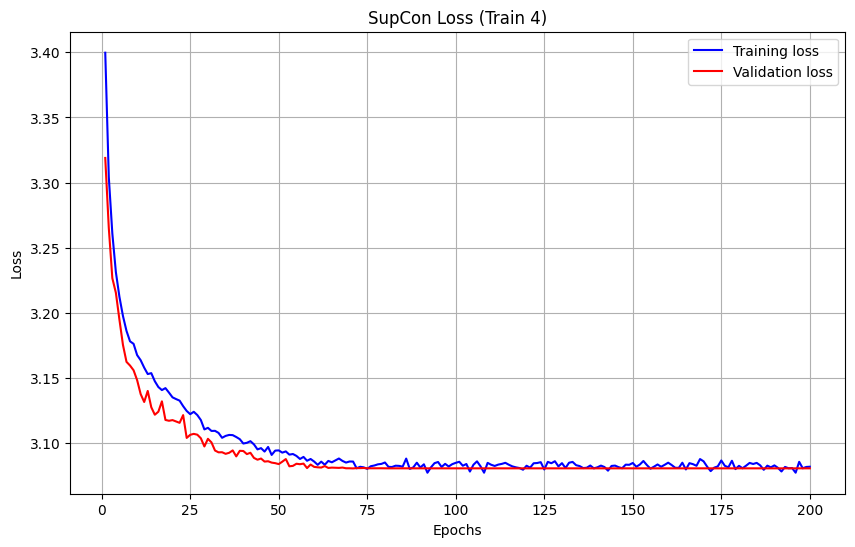


Step 4: Classifier Training (20 epochs)
Epoch 1/20 | Train Loss: 0.4654 | Val Loss: 0.3637 | Acc: 0.842
Epoch 2/20 | Train Loss: 0.3811 | Val Loss: 0.3491 | Acc: 0.850
Epoch 3/20 | Train Loss: 0.3618 | Val Loss: 0.3370 | Acc: 0.858
Epoch 4/20 | Train Loss: 0.3499 | Val Loss: 0.3443 | Acc: 0.862
Epoch 5/20 | Train Loss: 0.3368 | Val Loss: 0.3375 | Acc: 0.862
Epoch 6/20 | Train Loss: 0.3298 | Val Loss: 0.3295 | Acc: 0.858
Epoch 7/20 | Train Loss: 0.3258 | Val Loss: 0.3432 | Acc: 0.856
Epoch 8/20 | Train Loss: 0.3257 | Val Loss: 0.3282 | Acc: 0.862
Epoch 9/20 | Train Loss: 0.3129 | Val Loss: 0.3308 | Acc: 0.863
Epoch 10/20 | Train Loss: 0.3084 | Val Loss: 0.3235 | Acc: 0.856
Epoch 11/20 | Train Loss: 0.3068 | Val Loss: 0.3335 | Acc: 0.854
Epoch 12/20 | Train Loss: 0.3003 | Val Loss: 0.3297 | Acc: 0.866
Epoch 13/20 | Train Loss: 0.3017 | Val Loss: 0.3277 | Acc: 0.860
Epoch 14/20 | Train Loss: 0.2965 | Val Loss: 0.3389 | Acc: 0.871
Epoch 15/20 | Train Loss: 0.2904 | Val Loss: 0.3299 | Acc:

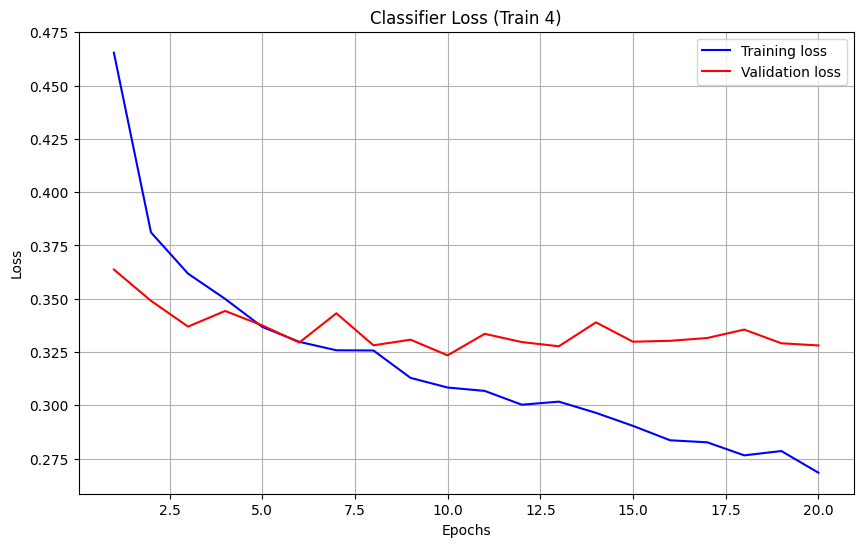


Step 5: Evaluation (with Asymmetric Threshold)

Finding optimal asymmetric threshold on validation set...
Testing 100 T0/T1 combinations...

✓ Best Thresholds: T0=0.4500, T1=0.3000 (F1=0.8642)

FINAL TEST RESULTS (with Asymmetric Threshold)

Test Accuracy:     0.8511
Test Precision:    0.8691
Test Recall:       0.8254
Test Specificity:  0.8766
Test F1-Score:     0.8467
Test ROC-AUC:      0.9272

=== Classification Report ===
                 precision    recall  f1-score   support

Non-binding (0)       0.83      0.88      0.86       381
    Binding (1)       0.87      0.83      0.85       378

       accuracy                           0.85       759
      macro avg       0.85      0.85      0.85       759
   weighted avg       0.85      0.85      0.85       759



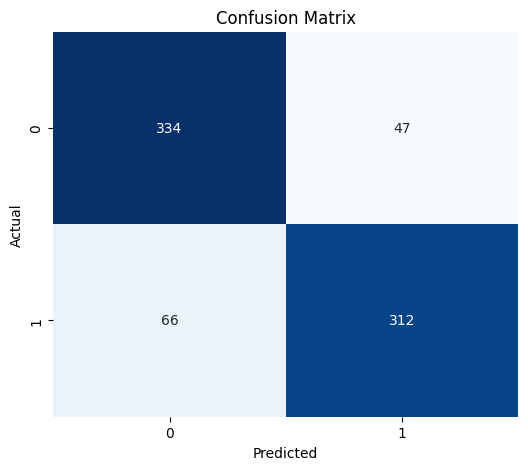


✓ Training Complete!


In [12]:
if __name__ == "__main__":
    # ===== CONFIGURATION (Train 4) =====
    csv_path = "/content/UniSwiss.csv"  # Replace with actual path
    output_dir = "./esm2_embeds_UniSwiss"

    # ===== Step 1: Load ESM2 Model =====
    print("\n" + "="*50)
    print("Step 1: Loading ESM2_t6_8M Model")
    print("="*50)

    tokenizer = AutoTokenizer.from_pretrained("facebook/esm2_t6_8M_UR50D")
    esm2_model = AutoModel.from_pretrained("facebook/esm2_t6_8M_UR50D").to(device)
    esm2_model.eval()
    print("✓ ESM2 model loaded")

    # ===== Step 2: Prepare Data =====
    print("\n" + "="*50)
    print("Step 2: Preparing Data with Mean Pooling")
    print("="*50)

    X_train_full, y_train_full, X_test, y_test = prepare_data(
        csv_path, output_dir, "UniSwiss", tokenizer, esm2_model, device
    )

    # Split for validation
    val_size = len(X_test)
    if len(X_train_full) > val_size:
        print(f"\nSplitting Training Data to create Validation Set (Size: {val_size})...")
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full, y_train_full,
            test_size=val_size,
            random_state=42,
            stratify=y_train_full
        )
    else:
        print("Training set too small. Using Test set as Validation.")
        X_train, y_train = X_train_full, y_train_full
        X_val, y_val = X_test, y_test

    print(f"\nFinal Input Shapes:")
    print(f"  Train: {X_train.shape}")
    print(f"  Val:   {X_val.shape}")
    print(f"  Test:  {X_test.shape}")

    # Create DataLoaders (batch_size=32, Train 4 config)
    train_loader = DataLoader(SequenceDataset(X_train, y_train), batch_size=32, shuffle=True)
    val_loader = DataLoader(SequenceDataset(X_val, y_val), batch_size=32)
    test_loader = DataLoader(SequenceDataset(X_test, y_test), batch_size=32)

    # ===== Step 3: SupCon Pretraining (Train 4: 200 epochs) =====
    print("\n" + "="*50)
    print("Step 3: SupCon Pretraining (200 epochs)")
    print("="*50)

    backbone = ESMBackbone(proj_dim=128, in_dim=320)
    backbone, supcon_train, supcon_val = train_supcon(
        backbone, train_loader, val_loader,
        epochs=200, lr=1e-4, device=device
    )

    # Save backbone
    torch.save(backbone.state_dict(), "supcon_esm2_backbone.pt")
    print("\n✓ Backbone saved to supcon_esm2_backbone.pt")

    # Plot SupCon losses
    plot_losses(supcon_train, supcon_val, "SupCon Loss (Train 4)")

    # ===== Step 4: Classifier Training (Train 4: 20 epochs) =====
    print("\n" + "="*50)
    print("Step 4: Classifier Training (20 epochs)")
    print("="*50)

    classifier = MLPClassifier(input_dim=backbone.hidden_dim)
    classifier, clf_train, clf_val, clf_acc = train_classifier(
        backbone, classifier, train_loader, val_loader,
        epochs=20, lr=1e-3, device=device
    )

    # Save classifier
    torch.save(classifier.state_dict(), "mlp_classifier.pt")
    print("\n✓ Classifier saved to mlp_classifier.pt")

    # Plot classifier losses
    plot_losses(clf_train, clf_val, "Classifier Loss (Train 4)")

    # ===== Step 5: Evaluation with Asymmetric Threshold =====
    print("\n" + "="*50)
    print("Step 5: Evaluation (with Asymmetric Threshold)")
    print("="*50)

    # Create full model
    model = FullModel(backbone, classifier).to(device)

    # Get predictions on validation set to find best threshold
    print("\nFinding optimal asymmetric threshold on validation set...")
    _, y_val_true, _, y_val_probs = evaluate_model(
        model, val_loader, device=device, return_preds=True
    )

    # Search for best threshold
    threshold_range = np.arange(0.3, 0.8, 0.05)
    best_thresholds, best_f1 = find_best_asymmetric_threshold(
        y_val_probs[:, 1], y_val_true, threshold_range
    )
    T0, T1 = best_thresholds
    print(f"\n✓ Best Thresholds: T0={T0:.4f}, T1={T1:.4f} (F1={best_f1:.4f})")

    # Evaluate on TEST set with best threshold
    print("\n" + "="*50)
    print("FINAL TEST RESULTS (with Asymmetric Threshold)")
    print("="*50)

    metrics, y_true, y_pred, y_probs = evaluate_model(
        model, test_loader, device=device,
        return_preds=True, use_threshold=(T0, T1)
    )

    print(f"\nTest Accuracy:     {metrics['Accuracy']:.4f}")
    print(f"Test Precision:    {metrics['Precision']:.4f}")
    print(f"Test Recall:       {metrics['Recall']:.4f}")
    print(f"Test Specificity:  {metrics['Specificity']:.4f}")
    print(f"Test F1-Score:     {metrics['F1-Score']:.4f}")
    print(f"Test ROC-AUC:      {metrics['ROC-AUC']:.4f}")

    print("\n=== Classification Report ===")
    print(classification_report(y_true, y_pred, target_names=["Non-binding (0)", "Binding (1)"]))

    # Plot confusion matrix
    plot_confusion_matrix(y_true, y_pred)

    print("\n" + "="*50)
    print("✓ Training Complete!")
    print("="*50)

In [11]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
